# Save new events

In [1]:
import numpy as np
import pandas as pd
import requests

from tqdm import tqdm
tqdm.pandas()

In [2]:
pd.set_option('display.max_columns', None)

In [ ]:
# def get_news_for_a_period(start_date: str, end_date: str, countries: list = None):
#     if countries is None:
#         countries = ['US', 'EU', 'GB', 'JP', 'DE', 'FR', 'CA', 'AU', 'SG', 'SE']
#     countries = [country.upper() for country in countries]

#     start_date += 'T00:00:00'
#     end_date += 'T00:00:00'

#     url = 'https://economic-calendar.tradingview.com/events'
#     headers = {
#         'Origin': 'https://in.tradingview.com'
#     }
#     payload = {
#         'from': start_date + '.000Z',
#         'to': end_date + '.000Z',
#         'countries': ','.join(countries or []),
#     }
#     data = requests.get(url, headers=headers, params=payload).json()
#     data = pd.DataFrame(data['result'])
#     return data

In [37]:
def get_news_for_a_period(start_date: str, end_date: str, countries: list = None):
    if countries is None:
        countries = ['US', 'EU', 'GB', 'JP', 'DE', 'FR', 'CA', 'AU', 'SG', 'SE']
    countries = [country.upper() for country in countries]

    start_date += 'T00:00:00'
    end_date += 'T00:00:00'

    url = 'https://economic-calendar.tradingview.com/events'
    headers = {
        'Origin': 'https://in.tradingview.com',
        "User-Agent": "Mozilla/5.0",
        "Accept": "application/json"
    }
    payload = {
        'from': start_date + '.000Z',
        'to': end_date + '.000Z',
        'countries': ','.join(countries or []),
    }
    data = requests.get(url, headers=headers, params=payload).json()
    data = pd.DataFrame(data['result'])
    return data

In [38]:
# def get_news_for_a_period(start_date: str, end_date: str, countries: list = None):
#     if countries is None:
#         countries = ['US', 'EU', 'GB', 'JP', 'DE', 'FR', 'CA', 'AU', 'SG', 'SE']
#     start = pd.to_datetime(start_date).tz_localize("UTC")
#     end = pd.to_datetime(end_date).tz_localize("UTC") + pd.Timedelta(days=1)  # make inclusive
#     url = "https://economic-calendar.tradingview.com/events"
#     headers = {
#         "Origin": "https://www.tradingview.com",
#         "User-Agent": "Mozilla/5.0",
#         "Accept": "application/json",
#     }
#     params = {
#         "from": start.strftime("%Y-%m-%dT%H:%M:%S.000Z"),
#         "to": end.strftime("%Y-%m-%dT%H:%M:%S.000Z"),
#         "countries": ",".join([c.upper() for c in countries]),
#     }
#     data = requests.get(url, headers=headers, params=params).json()
#     return pd.DataFrame(data["result"])


In [49]:
START_DATE = '2024-11-01'
END_DATE = '2024-11-30'

In [4]:
from datetime import datetime, timedelta

In [ ]:
today = datetime.now()
today

datetime.datetime(2026, 5, 5, 20, 18, 26, 787718)

In [45]:
start_date = (today + timedelta(days=1)).date()
end_date = start_date + timedelta(days=1)
print(start_date)
print(end_date)

2026-05-06
2026-05-07


In [46]:
df = get_news_for_a_period(start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d'))

In [47]:
df['date'].min()

'2026-05-06T00:00:00.000Z'

In [48]:
df['date'].max()

'2026-05-06T23:50:00.000Z'

In [49]:
df.shape

(55, 22)

In [50]:
df.head()

,id,title,country,indicator,category,period,referenceDate,source,source_url,actual,previous,forecast,actualRaw,previousRaw,forecastRaw,currency,importance,date,comment,ticker,unit,scale
0,415886,Constitution Memorial Day,JP,Holidays,gov,,None,,,None,NaN,NaN,None,NaN,NaN,JPY,-1,2026-05-06T00:00:00.000Z,NaN,NaN,NaN,NaN
1,404544,S&P Global PMI,SG,Composite PMI,NaN,Apr,2026-04-30T00:00:00Z,S&P Global,https://www.pmi.spglobal.com/public,None,56.7,NaN,None,56.7,NaN,SGD,-1,2026-05-06T00:30:00.000Z,The S&P Global Singapore Purchasing Managers’ ...,NaN,NaN,NaN
2,419405,RBA Chart Pack,AU,Interest Rate,mny,,None,Reserve Bank,http://www.rba.gov.au/,None,NaN,NaN,None,NaN,NaN,AUD,-1,2026-05-06T01:30:00.000Z,"In Australia, interest rates decisions are tak...",ECONOMICS:AUINTR,NaN,NaN
3,408074,Inflation Rate MoM Prel,SE,Inflation Rate MoM,prce,Apr,2026-04-30T00:00:00Z,Statistics Sweden,https://www.scb.se/,None,-0.6,-0.2,None,-0.6,-0.2,SEK,-1,2026-05-06T06:00:00.000Z,Inflation Rate MoM measures month over month c...,ECONOMICS:SEIRMM,%,NaN
4,408630,Inflation Rate YoY Prel,SE,Inflation Rate,prce,Apr,2026-04-30T00:00:00Z,Statistics Sweden,https://www.scb.se/,None,0.6,0.3,None,0.6,0.3,SEK,-1,2026-05-06T06:00:00.000Z,"In Sweden, the most important categories in th...",ECONOMICS:SEIRYY,%,NaN


In [27]:
df.sort_values(by='date', ascending=True, inplace=True)

In [28]:
df.tail()

,id,title,country,indicator,category,period,referenceDate,source,source_url,actual,previous,forecast,actualRaw,previousRaw,forecastRaw,currency,importance,date,ticker,comment,scale,unit
1368,395678,ISM Manufacturing New Orders,US,ISM Manufacturing New Orders,bsnss,Apr,2026-04-30T00:00:00Z,Institute for Supply Management,https://www.ismworld.org,54.1,53.5,NaN,54.1,53.5,NaN,USD,-1,2026-05-01T14:00:00.000Z,ECONOMICS:USMNO,The Manufacturing ISM Report On Business is ba...,NaN,NaN
1370,395680,ISM Manufacturing Employment,US,ISM Manufacturing Employment,bsnss,Apr,2026-04-30T00:00:00Z,Institute for Supply Management,https://www.ismworld.org,46.4,48.7,49.0,46.4,48.7,49.0,USD,0,2026-05-01T14:00:00.000Z,ECONOMICS:USMEMP,The Manufacturing ISM Report On Business is ba...,NaN,NaN
1372,395682,Baker Hughes Total Rigs Count,US,Total Rigs,enrg,May/01,2026-05-01T00:00:00Z,Baker Hughes Company,https://www.bakerhughes.com/,547.0,544.0,NaN,547.0,544.0,NaN,USD,-1,2026-05-01T17:00:00.000Z,ECONOMICS:USTRG,US Total Rigs refer to the number of active US...,NaN,NaN
1371,395681,Baker Hughes Oil Rig Count,US,Crude Oil Rigs,enrg,May/01,2026-05-01T00:00:00Z,Baker Hughes Company,https://www.bakerhughes.com/,408.0,407.0,NaN,408.0,407.0,NaN,USD,-1,2026-05-01T17:00:00.000Z,ECONOMICS:USCOR,US Crude Oil Rigs refer to the number of activ...,NaN,NaN
1373,407828,SIPMM Manufacturing PMI,SG,Manufacturing PMI,NaN,Apr,2026-04-30T00:00:00Z,Institute of Purchasing and Materials Manageme...,https://sipmm.edu.sg/,50.7,50.5,NaN,50.7,50.5,NaN,SGD,-1,2026-05-02T13:00:00.000Z,ECONOMICS:SGMPMI,The Singapore PMI is a key barometer of a manu...,NaN,NaN


In [6]:
df['date'] = pd.to_datetime(df['date'])
df['referenceDate'] = pd.to_datetime(df['referenceDate'])

In [12]:
df.country.value_counts()[:10]

country
US    283
EU     78
GB     74
JP     72
DE     68
FR     58
CA     48
ES     39
AU     38
IT     36
Name: count, dtype: int64

In [46]:
# freq='MS' означает Month Start (начало месяца)
dates = pd.date_range(start='2024-01-01', end='2024-12-01', freq='MS').strftime('%Y-%m-%d').tolist()
for date in dates:
    print(date)

2024-01-01
2024-02-01
2024-03-01
2024-04-01
2024-05-01
2024-06-01
2024-07-01
2024-08-01
2024-09-01
2024-10-01
2024-11-01
2024-12-01


In [48]:
df = get_news_for_a_period('2024-11-01', '2024-12-01')

In [50]:
df.head()

,id,title,country,indicator,category,period,referenceDate,source,source_url,actual,previous,forecast,actualRaw,previousRaw,forecastRaw,currency,importance,date,ticker,comment,unit,scale
0,340569,All Saints’ Day,FR,Holidays,gov,,None,,,NaN,NaN,NaN,NaN,NaN,NaN,EUR,-1,2024-11-01T00:00:00.000Z,NaN,NaN,NaN,NaN
1,359702,CoreLogic Dwelling Prices MoM,AU,CoreLogic Dwelling Prices MoM,hse,Oct,2024-10-31T00:00:00Z,Cotality,https://www.corelogic.com.au/,0.3,0.4,NaN,0.3,0.4,NaN,AUD,-1,2024-11-01T00:01:00.000Z,ECONOMICS:AUCLDPMM,"In Australia, the Cotality Home Value Index ai...",%,NaN
2,359401,PPI YoY,AU,Producer Prices Change,prce,Q3,2024-09-30T00:00:00Z,Bureau of Statistics,http://www.abs.gov.au,3.9,4.8,NaN,3.9,4.8,NaN,AUD,-1,2024-11-01T00:30:00.000Z,ECONOMICS:AUPPIYY,"In Australia, Producer Prices Change measures ...",%,NaN
3,359402,PPI QoQ,AU,Producer Price Inflation MoM,prce,Q3,2024-09-30T00:00:00Z,Bureau of Statistics,http://www.abs.gov.au,0.9,1.0,0.7,0.9,1.0,0.7,AUD,0,2024-11-01T00:30:00.000Z,ECONOMICS:AUPPIMM,"In Australia, the Producer Price Inflation QoQ...",%,NaN
4,359703,Investment Lending for Homes,AU,Investment Lending For Homes,hse,Sep,2024-09-30T00:00:00Z,Bureau of Statistics,http://www.abs.gov.au,-1.0,1.8,NaN,-1.0,1.8,NaN,AUD,0,2024-11-01T00:30:00.000Z,ECONOMICS:AUILH,NaN,%,NaN


In [8]:
from datetime import date, timedelta
import calendar
import time
from tqdm import tqdm

In [9]:
def get_month_ranges(start_year=2020):
    """
    Generate start and end dates for each month from start_year to current year/month.
    Returns a list of tuples: [(start_date, end_date), ...]
    Dates are in 'YYYY-MM-DD' string format.
    """
    today = date.today()
    ranges = []

    for year in range(start_year, today.year + 1):
        # Determine the last month to process for the current year
        end_month = 12 if year < today.year else today.month
        for month in range(1, end_month + 1):
            start_date = date(year, month, 1)
            last_day = calendar.monthrange(year, month)[1]
            end_date = date(year, month, last_day)
            ranges.append((start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')))

    return ranges

In [10]:
month_ranges = get_month_ranges(start_year=2020)

In [12]:
print(month_ranges)

[('2020-01-01', '2020-01-31'), ('2020-02-01', '2020-02-29'), ('2020-03-01', '2020-03-31'), ('2020-04-01', '2020-04-30'), ('2020-05-01', '2020-05-31'), ('2020-06-01', '2020-06-30'), ('2020-07-01', '2020-07-31'), ('2020-08-01', '2020-08-31'), ('2020-09-01', '2020-09-30'), ('2020-10-01', '2020-10-31'), ('2020-11-01', '2020-11-30'), ('2020-12-01', '2020-12-31'), ('2021-01-01', '2021-01-31'), ('2021-02-01', '2021-02-28'), ('2021-03-01', '2021-03-31'), ('2021-04-01', '2021-04-30'), ('2021-05-01', '2021-05-31'), ('2021-06-01', '2021-06-30'), ('2021-07-01', '2021-07-31'), ('2021-08-01', '2021-08-31'), ('2021-09-01', '2021-09-30'), ('2021-10-01', '2021-10-31'), ('2021-11-01', '2021-11-30'), ('2021-12-01', '2021-12-31'), ('2022-01-01', '2022-01-31'), ('2022-02-01', '2022-02-28'), ('2022-03-01', '2022-03-31'), ('2022-04-01', '2022-04-30'), ('2022-05-01', '2022-05-31'), ('2022-06-01', '2022-06-30'), ('2022-07-01', '2022-07-31'), ('2022-08-01', '2022-08-31'), ('2022-09-01', '2022-09-30'), ('2022-10

In [ ]:
not_full_month = []
pb = tqdm(month_ranges)
for start, end in pb:
    # print(f"start_date = '{start}' and end_date = '{end}'")
    pb.set_description(f"Processing {start} to {end}")
    month_events = get_news_for_a_period(start, end)
    if len(month_events) == 2000:
        not_full_month.append(start)
        print(f'[ALERT] Not full month: {start}')
    time.sleep(1)


In [57]:
import pandas as pd
from datetime import datetime, timedelta
import time

def collect_economic_events_tradingview(start_year: int, end_year: int) -> pd.DataFrame:
    """
    Collect economic events from TradingView month by month and concatenate into years.
    
    Parameters:
        start_year (int): First year to collect data for
        end_year (int): Last year to collect data for (inclusive)
    
    Returns:
        pd.DataFrame: Concatenated dataframe of all economic events
    """
    all_data = []
    
    # Determine the last allowed month
    today = datetime.today()
    first_date_of_current_month = datetime(today.year, today.month, 1)
    last_allowed_date = first_date_of_current_month - timedelta(days=1)
    
    for year in range(start_year, end_year + 1):
        # Skip future years
        if year > last_allowed_date.year:
            break
            
        year_data = []
        
        with tqdm(range(1, 13), leave=True, desc=f"{year}") as pbar:
            for month in pbar:
                start_date = datetime(year, month, 1)
                
                # Handle December case for end date
                if month == 12:
                    end_date = datetime(year + 1, 1, 1) - timedelta(days=1)
                else:
                    end_date = datetime(year, month + 1, 1) - timedelta(days=1)
                
                # Skip months beyond the last allowed date
                if start_date > last_allowed_date:
                    tqdm.write(f"Alert: Have reached last allowed date {last_allowed_date.strftime('%Y-%m-%d')}. Stopping.")
                    break
                
                # Clamp end_date to last_allowed_date if it goes beyond
                if end_date > last_allowed_date:
                    end_date = last_allowed_date
                
                # Update tqdm postfix to show current date range
                pbar.set_postfix({"start": start_date.strftime('%Y-%m-%d'), "end": end_date.strftime('%Y-%m-%d')})
                
                month_data = get_news_for_a_period(start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d'))
                # month_data = pd.DataFrame({'dummy': [1, 2, 3]})
                
                # Check if data was cropped (len == 2000)
                if len(month_data) >= 2000:
                    tqdm.write(f"Warning: Data for {year}-{month:02d} may be cropped (length = {len(month_data)})")
                
                year_data.append(month_data)
                
                # Pause between downloads to avoid being banned
                time.sleep(3)  # 3 seconds pause, adjust as needed
        
        # Concatenate all months for the year
        if year_data:
            year_df = pd.concat(year_data, ignore_index=True)
            year_df.to_csv(f"economic_events/economic_events_{year}.csv", index=False)
            all_data.append(year_df)
        
        # Optional: longer pause between years
        time.sleep(7)
    
    # Concatenate all years
    final_df = pd.concat(all_data, ignore_index=True)
    return final_df

In [58]:
df = collect_economic_events_tradingview(2020, 2026)

2026:  25%|██▌       | 3/12 [00:12<00:36,  4.01s/it, start=2026-03-01, end=2026-03-31]


Alert: Have reached last allowed date 2026-03-31. Stopping.


In [ ]:
df2 = collect_economic_events_tradingview(2013, 2019)

2020: 100%|██████████| 12/12 [00:47<00:00,  3.96s/it, start=2020-12-01, end=2020-12-31]


In [73]:
events = pd.concat([df2, df], ignore_index=True)
events.shape

(99029, 22)

In [75]:
events.to_csv('economic_events/economic_events.csv', index=False)


# Download prices

## Download through MetaTrader 5

In [53]:
import pytz
from datetime import datetime
import MetaTrader5 as mt5

In [54]:
timezone = pytz.timezone("Etc/UTC")
datetime.now(tz=timezone)

datetime.datetime(2026, 4, 16, 22, 9, 9, 738698, tzinfo=<StaticTzInfo 'Etc/UTC'>)

In [57]:
def download_ticker_mt5(ticker: str, utc_from: datetime, date_to: datetime=datetime.now()):
    ticker = ticker.upper()

    # set time zone to UTC
    timezone = pytz.timezone("Etc/UTC")

    # create 'datetime' object in UTC time zone to avoid the implementation of a local time zone offset
    # utc_from = datetime(2015, 1, 10, tzinfo=timezone)
    # date_to = datetime.now()

    # get rates
    rates = mt5.copy_rates_range(ticker, mt5.TIMEFRAME_H1, utc_from, date_to)

    df = pd.DataFrame(rates)
    df['time']=pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)


In [59]:
import MetaTrader5 as mt5
from datetime import datetime
import pytz

In [60]:
mt5.initialize()

True

In [67]:
# set time zone to UTC
timezone = pytz.timezone("Etc/UTC")
# create 'datetime' object in UTC time zone to avoid the implementation of a local time zone offset
utc_from = datetime(2026, 1, 1, tzinfo=timezone)
date_to = datetime.now()
# get 10 EURUSD H4 bars starting from 01.10.2020 in UTC time zone
rates = mt5.copy_rates_range("EURUSD", mt5.TIMEFRAME_M30, utc_from, date_to)

df = pd.DataFrame(rates)
df['time']=pd.to_datetime(df['time'], unit='s')

In [68]:
df.head()

,time,open,high,low,close,tick_volume,spread,real_volume
0,2026-01-02 08:00:00,1.17546,1.17564,1.17542,1.17562,441,12,0
1,2026-01-02 08:30:00,1.17563,1.17573,1.17503,1.17507,697,12,0
2,2026-01-02 09:00:00,1.17508,1.17509,1.17427,1.17431,1071,12,0
3,2026-01-02 09:30:00,1.17430,1.17449,1.17410,1.17432,845,12,0
4,2026-01-02 10:00:00,1.17433,1.17466,1.17410,1.17411,1593,12,0


# Download prices using TwelveData

In [4]:
from pathlib import Path
import sys

_repo_root = Path("..").resolve()
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from config import Config

In [5]:
import pytz
import pandas as pd
from twelvedata import TDClient

In [6]:
timezone = pytz.timezone("Etc/UTC")

In [8]:
client = TDClient(apikey=Config.TWELVE_API, timezone=timezone)

In [7]:
def download_prices(client: TDClient, ticker: str, outputsize: int = 5000, interval: str = "30min", **kwargs) -> pd.DataFrame:
    # Get the last N bars of the ticker
    bars = client.time_series(
        symbol=ticker,
        interval=interval,
        outputsize=outputsize,
        **kwargs
    )
    return bars.as_pandas()

In [10]:
br = download_prices(client, 'EUR/USD', interval='1h', outputsize=5000)

In [33]:
br.index.min().to_pydatetime()

datetime.datetime(2025, 8, 18, 14, 0)

In [13]:
br.index.min()

Timestamp('2025-08-18 14:00:00')

In [11]:
br.reset_index().head()

,datetime,open,high,low,close
0,2026-04-26 18:00:00,1.17163,1.17201,1.17161,1.17184
1,2026-04-26 17:00:00,1.17158,1.17207,1.17157,1.17165
2,2026-04-26 16:00:00,1.17209,1.17214,1.17146,1.17161
3,2026-04-26 15:00:00,1.17291,1.17296,1.17202,1.17212
4,2026-04-26 14:00:00,1.17167,1.17296,1.17160,1.17294


In [ ]:
br

In [9]:
tickers = [
    'AUDCAD',
    'AUDUSD',
    'EURAUD',
    'EURCAD',
    'EURGBP',
    'EURUSD',
    'GBPCHF',
    'GBPUSD',
    'NZDUSD',
    'USDCAD',
    'USDCHF',
    'USDJPY'
]
tickers = [t[:-3] + '/' + t[-3:] for t in tickers]

In [10]:
print(tickers)

['AUD/CAD', 'AUD/USD', 'EUR/AUD', 'EUR/CAD', 'EUR/GBP', 'EUR/USD', 'GBP/CHF', 'GBP/USD', 'NZD/USD', 'USD/CAD', 'USD/CHF', 'USD/JPY']


In [11]:
from tqdm import tqdm
from time import sleep

In [13]:
pbar = tqdm(tickers)

for ticker in pbar:
    pbar.set_description(f"Processing {ticker} data")
    pbar.set_postfix({"status": "Downloading..."})
    prices = download_prices(client, ticker, outputsize=5000, interval="1h")
    prices.reset_index(inplace=True)
    ticker = ticker.replace("/", "")
    pbar.set_postfix({"status": "Saving..."})
    prices.to_csv(f"prices_h1/{ticker}_H1.csv", index=False)
    pbar.set_postfix({"status": "Sleep 30 seconds..."})
    sleep(30)

> Download all available data from TwelveData and join the rest available prices from MetaTrader5

In [14]:
import pytz
from datetime import datetime
import MetaTrader5 as mt5

In [22]:
mt5.initialize()

True

In [3]:
def download_ticker_mt5(ticker: str, utc_from: datetime, date_to: datetime=datetime.now()):
    ticker = ticker.upper()

    # get rates
    rates = mt5.copy_rates_range(ticker, mt5.TIMEFRAME_H1, utc_from, date_to)

    df = pd.DataFrame(rates)
    df['time']=pd.to_datetime(df['time'], unit='s')
    # df.set_index('time', inplace=True)
    
    return df

In [33]:
def download_ticker_mt5_from(ticker: str, tf = mt5.TIMEFRAME_H1, date_to: datetime=datetime.now(), n_last: int = 99000):
    ticker = ticker.upper()

    # get rates
    rates = mt5.copy_rates_from(ticker, tf, date_to, n_last)

    df = pd.DataFrame(rates)
    df['time']=pd.to_datetime(df['time'], unit='s')
    df.rename(columns={'time': 'datetime'}, inplace=True)
    
    return df

In [34]:
mt = download_ticker_mt5_from("EURUSD", date_to=datetime(2023, 11, 1), n_last=99000)

In [44]:
pbar = tqdm(tickers)

for ticker in pbar:
    pbar.set_description(f"Processing {ticker} data...")
    ticker = ticker.replace("/", "")

    tw = pd.read_csv(f"prices_h1/{ticker}_H1.csv")
    tw['datetime'] = pd.to_datetime(tw['datetime'])
    tw.sort_values(by='datetime', ascending=True, inplace=True)
    min_date = tw['datetime'].min().to_pydatetime()

    tw = tw[tw['datetime'].dt.dayofweek < 5]
    tw = tw[['datetime', 'open', 'high', 'low', 'close']]

    mt = download_ticker_mt5_from(ticker, date_to=datetime.now(), n_last=99000)
    mt = mt[mt['datetime'] < min_date]
    mt = mt[['datetime', 'open', 'high', 'low', 'close']]

    prices = pd.concat([mt, tw], ignore_index=True)
    prices.to_csv(f"mt5_twelve_union_prices_h1/{ticker}_H1.csv", index=False)

Processing USD/JPY data...: 100%|██████████| 12/12 [00:04<00:00,  2.94it/s]


> Unite prices with MT5

In [17]:
import pytz
from datetime import datetime
import MetaTrader5 as mt5

In [18]:
mt5.initialize()

True

In [19]:
timezone = pytz.timezone("Etc/UTC")
utc_from = datetime(2015, 1, 1, tzinfo=timezone)
utc_to = datetime.now(tz=timezone)

In [21]:
def download_ticker_mt5_from(ticker: str, tf = mt5.TIMEFRAME_H1, date_to: datetime=datetime.now(), n_last: int = 99000):
    ticker = ticker.upper()

    # get rates
    rates = mt5.copy_rates_from(ticker, tf, date_to, n_last)

    df = pd.DataFrame(rates)
    df['time']=pd.to_datetime(df['time'], unit='s')
    df.rename({'time': 'datetime'}, inplace=True)
    
    return df

In [22]:
def download_ticker_mt5(ticker: str, utc_from: datetime, date_to: datetime=datetime.now()):
    ticker = ticker.upper()

    # get rates
    rates = mt5.copy_rates_range(ticker, mt5.TIMEFRAME_H1, utc_from, date_to)

    df = pd.DataFrame(rates)
    df['time']=pd.to_datetime(df['time'], unit='s')
    # df.set_index('time', inplace=True)
    
    return df

In [ ]:
for ticker in pbar:
    pbar.set_description(f"Processing {ticker} data...")
    mt_prices = download_ticker_mt5_from(ticker)
    tw_prices = pd.read_csv(f"prices_h1/{ticker}_H1.csv")
    tw_prices['datetime'] = pd.to_datetime(tw_prices['datetime'])
    tw_prices.sort_values(by='datetime', ascending=True, inplace=True)
    min_tw_date = tw_prices['datetime'].min()
    mt_prices = 

In [9]:
td = TDClient(apikey=Config.TWELVE_API)

In [10]:
lst = td.get_forex_pairs_list()

In [17]:
pairs = pd.DataFrame(lst.as_csv())

In [ ]:
pairs

,0,1,2,3
0,symbol,currency_group,currency_base,currency_quote
1,AED/ARS,Exotic-Cross,UAE Dirham,Argentinian Peso
2,AED/AUD,Exotic-Cross,UAE Dirham,Australian Dollar
3,AED/BBD,Exotic-Cross,UAE Dirham,Barbadian Dollar
4,AED/BRL,Exotic-Cross,UAE Dirham,Brazil Real
...,...,...,...,...
1455,ZAR/USD,Exotic,South African Rand,US Dollar
1456,ZAR/VEF,Exotic-Cross,South African Rand,Venezuelan Bolivar
1457,ZAR/XAF,Exotic-Cross,South African Rand,Central African CFA franc
1458,ZAR/XCD,Exotic-Cross,South African Rand,East Caribbean Dollar


In [21]:
all([t for t in tickers if t in pairs[0].values])

True

# Add prices to existed prices

In [1]:
import os
import pandas as pd

In [2]:
prev_prices_dir = "../dataset/historical_prices/"
new_prices_dir = "prices26/"

In [5]:
tickers = [
    'AUDCAD',
    'AUDUSD',
    'EURAUD',
    'EURCAD',
    'EURGBP',
    'EURUSD',
    'GBPCHF',
    'GBPUSD',
    'NZDUSD',
    'USDCAD',
    'USDCHF',
    'USDJPY'
]

In [3]:
prev_tickers = os.listdir(prev_prices_dir)
new_tickers = os.listdir(new_prices_dir)

In [8]:
def read_pair(pair: str, path2folder: str = "..\\dataset\\historical_prices\\"):
    return pd.read_csv(f'{path2folder}\\{pair}_M30.csv',
                        sep="\t",
                        names=["time", "open", "high", "low", "close", "volume", "spread"],
                        header=0,
                        parse_dates=["time"])

In [76]:
from datetime import datetime
import pytz
import numpy as np

# Set timezone
sydney_tz = pytz.timezone("Australia/Sydney")

In [78]:
for ticker in tickers:
    print(f"Processing {ticker}")
    
    # Load previous and new prices
    prev_prices = pd.read_csv(os.path.join(prev_prices_dir, ticker + "_M30" + ".csv"),
                        sep="\t",
                        names=["time", "open", "high", "low", "close", "volume", "spread"],
                        header=0,
                        parse_dates=["time"])
    new_prices = pd.read_csv(os.path.join(new_prices_dir, ticker + "_M30_2026" + ".csv"))

    # Calibrate data
    new_prices.columns = ['time', 'open', 'high', 'low', 'close']
    # new_prices already in Sydney time; ensure it is tz-aware
    infer_dst = np.array([False] * new_prices.shape[0])
    new_prices['time'] = pd.to_datetime(new_prices['time'], utc=False).dt.tz_localize("Australia/Sydney", ambiguous=infer_dst).dt.tz_convert("GMT")
    new_prices.sort_values(by='time', inplace=True)
    new_prices = new_prices[new_prices['time'] >= '2026-01-01']

    # prev_prices: parse as UTC then convert to Sydney to align zones
    prev_prices['time'] = pd.to_datetime(prev_prices['time'], utc=True)
    prev_prices.sort_values(by='time', inplace=True)
    prev_prices = prev_prices[prev_prices['time'] < '2026-01-01']

    # Concatenate on aligned Sydney-time columns
    prices = pd.concat([prev_prices[['time', 'open', 'high', 'low', 'close']], new_prices], axis=0)
    prices.sort_values(by='time', inplace=True)
    prices.reset_index(drop=True, inplace=True)

    # Save data
    prices.to_csv(os.path.join('prices', ticker + "_M30" + ".csv"), index=False, sep=",")


Processing AUDCAD
Processing AUDUSD
Processing EURAUD
Processing EURCAD
Processing EURGBP
Processing EURUSD
Processing GBPCHF
Processing GBPUSD
Processing NZDUSD
Processing USDCAD
Processing USDCHF
Processing USDJPY


In [12]:
prev_prices.head()

,time,open,high,low,close,volume,spread
0,2009-12-29 15:30:00,0.93130,0.93273,0.93109,0.93212,388,56
1,2009-12-29 16:00:00,0.93216,0.93340,0.93203,0.93283,370,50
2,2009-12-29 16:30:00,0.93290,0.93290,0.93101,0.93101,450,52
3,2009-12-29 17:00:00,0.93106,0.93280,0.93106,0.93221,345,50
4,2009-12-29 17:30:00,0.93234,0.93325,0.93118,0.93253,373,52


In [13]:
new_prices.head()

,datetime,open,high,low,close
0,2026-04-17 06:30:00,0.98092,0.98105,0.98086,0.98097
1,2026-04-17 06:00:00,0.98141,0.98150,0.98090,0.98091
2,2026-04-17 05:30:00,0.98095,0.98146,0.98087,0.98144
3,2026-04-17 05:00:00,0.98068,0.98116,0.98064,0.98094
4,2026-04-17 04:30:00,0.98080,0.98102,0.98061,0.98072


In [15]:
new_prices.columns = ['time', 'open', 'high', 'low', 'close']


In [49]:
from datetime import datetime
import pytz

# Set timezone
sydney_tz = pytz.timezone("Australia/Sydney")

# Get current time in Sydney
sydney_time = datetime.now(sydney_tz)

print(sydney_time.strftime("%Y-%m-%d %H:%M:%S %Z%z"))

2026-04-17 08:05:40 AEST+1000


In [ ]:
new_prices['time'] = pd.to_datetime(new_prices['time'], utc=True).dt.tz_localize("Australia/Sydney")
new_prices.sort_values(by='time', inplace=True)
new_prices = new_prices[new_prices['time'] >= '2026-01-01']

TypeError: Already tz-aware, use tz_convert to convert.

In [18]:
prev_prices['time'] = pd.to_datetime(prev_prices['time'], utc=True)
prev_prices.sort_values(by='time', inplace=True)
prev_prices = prev_prices[prev_prices['time'] < '2026-01-01']

In [25]:
prices = pd.concat([prev_prices[['time', 'open', 'high', 'low', 'close']], new_prices], axis=0)

In [29]:
prices.reset_index(drop=True, inplace=True)

In [30]:
prices.head()

,time,open,high,low,close
0,2009-12-29 15:30:00+00:00,0.93130,0.93273,0.93109,0.93212
1,2009-12-29 16:00:00+00:00,0.93216,0.93340,0.93203,0.93283
2,2009-12-29 16:30:00+00:00,0.93290,0.93290,0.93101,0.93101
3,2009-12-29 17:00:00+00:00,0.93106,0.93280,0.93106,0.93221
4,2009-12-29 17:30:00+00:00,0.93234,0.93325,0.93118,0.93253


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid')

In [2]:
alpha = 0.05 - 0.01
quantile_levels = [alpha, 1 - alpha]
quantile_str = str(quantile_levels).replace('[','').replace(']','')
quantile_str

'0.04, 0.96'

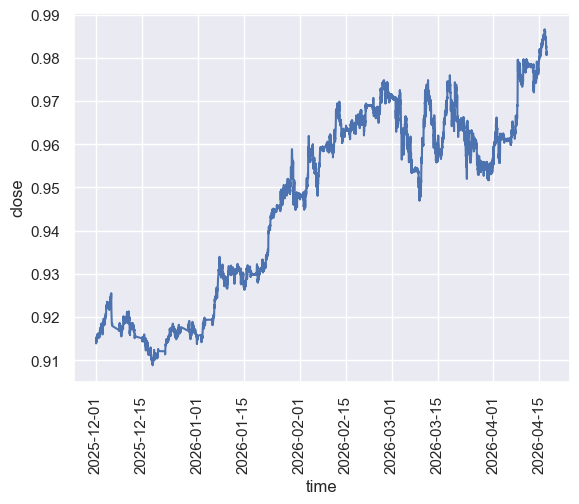

In [40]:
sns.lineplot(x='time', y='close', data=prices[prices['time'] >= '2025-12-01'])
plt.xticks(rotation=90);
